# SINTON-IA: Hub di Validazione Churn Prevention
---
## 🧬 Sintesi Metodologica: Cross-Validation e Benchmarking

Questo notebook consolida la validazione scientifica del sistema SINTON-IA, integrando la **Mini-Batch Evaluation** con l'analisi dinamica degli scenari e il benchmarking rigoroso contro le baseline di riferimento.

### Caratteristiche del Sistema:
1.  **Generalizzazione su Popolazione**: Valutazione eseguita su batch rappresentativi dei cluster clinici (*Ghost*, *A Rischio*, *Engaged*, *Moderato*).
2.  **Scenario Analysis**: Analisi del bilanciamento tra obiettivi clinici (ritenzione) e vincoli operativi tramite variazione dei pesi.
3.  **Benchmarking GA vs Random Search**: Misurazione del guadagno algoritmico sulla media della popolazione.
4.  **Riproducibilità**: Esportazione automatica della configurazione ottimale per l'ambiente di produzione.

### Fasi della Pipeline:
1.  **Fase 1**: Selezione Set di Ottimizzazione e Test.
2.  **Fase 2**: Master Joint Hyperparameter Tuning (Optuna).
3.  **Fase 3**: Scenario Analysis (Risposta della Popolazione).
4.  **Fase 4**: Benchmark GA vs Random Search (Hold-out Test).
5.  **Fase 5**: Visualizzazione Performance e Convergenza.



In [1]:
# SINTON-IA: Hub Scientifico di Churn Prevention 
# ---
# Sintesi Finale: Cross-Validation, Scenari e Benchmarking

import os, sys, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, itertools
import logging, json, optuna
from datetime import datetime
from tqdm.notebook import tqdm
from numpy.random import SeedSequence, default_rng
from optuna.samplers import TPESampler
import optuna.visualization as vis

# Setup Path Robusto
SRC_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

from data_pipeline import DataPipeline
from genetic_algorithm import GAParams, GeneticAlgorithm, Chromosome, FitnessEvaluator

# Disattiva log ridondanti
logging.getLogger('genetic_algorithm').setLevel(logging.ERROR)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Configurazione Estetica Accademica
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
FIGURES_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..", "docs", "latex", "figures"))
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"[OK] Masterpiece Pipeline Pronta. Output grafici in: {FIGURES_DIR}")

[OK] Masterpiece Pipeline Pronta. Output grafici in: C:\Users\polic\Desktop\SINTON-IA\docs\latex\figures


## Fase 1: Selezione Set di Ottimizzazione e Test 
Identifichiamo due set di dati indipendenti per garantire la validità scientifica del processo:
- **Optimization Set**: Un batch di 40 pazienti stratificati (10 per ogni cluster clinico) utilizzato per il tuning dei parametri.
- **Hold-out Test Set**: Un set indipendente di pazienti mai analizzati durante la fase di tuning, utilizzato per la validazione finale delle performance e della capacità di generalizzazione.


In [2]:
## Fase 1: Selezione Set di Ottimizzazione e Test (Rigore Scientifico)
# Identifichiamo due set separati: uno per il tuning (Optimization) e uno per la validazione finale (Hold-out Test)

pipeline = DataPipeline(seed=42)
df_features = pipeline.run_aggregation(pipeline.run_generation(n_patients=200))

# Campionamento Stratificato: 10 pazienti per cluster per ogni set
optimization_set = df_features.groupby('profilo_assegnato').sample(n=10, random_state=42)
test_set = df_features.groupby('profilo_assegnato').sample(n=10, random_state=999) # Seed diverso = pazienti diversi

print(f"[OK] Dataset creati con Split Rigoroso:")
print(f" - Optimization Set (per Fasi 2 e 3): {len(optimization_set)} pazienti")
print(f" - Hold-out Test Set (per Fase 4): {len(test_set)} pazienti")

# Visualizziamo la distribuzione per conferma
print("\nDistribuzione Cluster (Optimization Set):")
print(optimization_set['profilo_assegnato'].value_counts())

[*] Generazione di 200 pazienti per 90 giorni...
[OK] Generazione completata.
[*] Aggregazione feature...
[OK] Aggregazione completata: 200 pazienti processati.
[OK] Dataset creati con Split Rigoroso:
 - Optimization Set (per Fasi 2 e 3): 40 pazienti
 - Hold-out Test Set (per Fase 4): 40 pazienti

Distribuzione Cluster (Optimization Set):
profilo_assegnato
A Rischio    10
Engaged      10
Ghost        10
Moderato     10
Name: count, dtype: int64


## Fase 2: Tuning dei Parametri tramite Ottimizzazione Bayesiana
Identificazione congiunta della combinazione ottimale di operatori genetici (Selezione, Crossover, Mutazione) e iperparametri numerici (dimensione popolazione, tasso di mutazione...). 
Il processo utilizza il framework Optuna per massimizzare la fitness media sull'intero Optimization Set, garantendo che la configurazione eletta sia efficace trasversalmente su tutti i cluster clinici.


In [3]:
## Fase 2: Master Joint Hyperparameter Tuning (Optuna)
import optuna.visualization as vis
import plotly.io as pio

def objective(trial):
    # 1. Configurazione iperparametri (Search Space)
    sel_method = trial.suggest_categorical("selection_method", ["tournament", "ranking", "roulette"])
    cross_method = trial.suggest_categorical("crossover_method", ["single-point", "two-point", "uniform"])
    mut_method = trial.suggest_categorical("mutation_method", ["adaptive", "flip-bit"])
    pop_size = trial.suggest_int("pop_size", 40, 150, step=10)
    mut_rate = trial.suggest_float("mutation_rate", 0.005, 0.02, log=True)
    
    pop_fitnesses = []
    
    # 2. Isolamento stocastico per trial tramite SeedSequence
    ss_trial = SeedSequence(trial.number + 42)
    child_seeds = ss_trial.spawn(len(optimization_set))
    
    # 3. Valutazione sul Batch (Internal Validation)
    for idx, (_, p_data) in enumerate(optimization_set.iterrows()):
        rng = default_rng(child_seeds[idx])
        params = GAParams(
            pop_size=pop_size, generations=40, mutation_rate=mut_rate,
            selection_method=sel_method, crossover_method=cross_method, 
            mutation_method=mut_method, load_gold_standard=False
        )
        ga = GeneticAlgorithm(FitnessEvaluator(p_data, params, rng=rng), params, rng=rng)
        pop_fitnesses.append(ga.run().fitness)
        
    avg_fit = np.mean(pop_fitnesses)
    min_fit = np.min(pop_fitnesses) 
    trial.set_user_attr("min_fitness", float(min_fit)) 
    
    return avg_fit

print(f"Avvio Master Joint Tuning con Optuna su {len(optimization_set)} pazienti...")

sampler = TPESampler(seed=42)
study = optuna.create_study(direction="maximize", study_name="SINTON-IA_Gold_Standard", sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

# --- DECISIONE ROBUSTA (Gerarchia: Media > Case-Stability > Efficiency) ---
sorted_trials = sorted([t for t in study.trials if t.value is not None], 
                    key=lambda t: (t.value,                             # 1. Massima performance media
                                   t.user_attrs.get("min_fitness", 0),  # 2. Massima stabilità (caso peggiore)
                                   -t.params.get('pop_size', 0)),      # 3. Minima popolazione (efficienza)
                    reverse=True)

best_trial = sorted_trials[0]
best_params = best_trial.params

# --- ANALISI CANDIDATI (Top 5 Near-Tie / Candidates) ---
print("\n" + "="*85)
print(f"{'STATO':<12} | {'SCORE':<8} | {'WORST-CASE':<10} | {'POP':<5} | {'OPERATORI'}")
print("-" * 85)

for i, t in enumerate(sorted_trials[:5]):
    status = "[WINNER]" if i == 0 else f"Rank {i+1}"
    p = t.params
    ops = f"{p['selection_method'][:4]}/{p['crossover_method'][:4]}/{p['mutation_method'][:4]}"
    print(f"{status:<12} | {t.value:.4f}   | {t.user_attrs.get('min_fitness', 0):.4f}     | {p['pop_size']:<5} | {ops}")
print("="*85)

# --- ESPORTAZIONE GRAFICI PER LATEX ---
try:
    # 06_optuna_parallel.png (Visualizzazione interazione iperparametri)
    fig_parallel = vis.plot_parallel_coordinate(study, params=["selection_method", "crossover_method", "mutation_method", "mutation_rate", "pop_size"])
    fig_parallel.update_layout(title="Interazione Iperparametri: Coordinata Parallela")
    fig_parallel.write_image(os.path.join(FIGURES_DIR, "06_optuna_parallel.png"), scale=2)
    
    print(f"[OK] Asset Optuna generato: 06_optuna_parallel.png")
    display(fig_parallel)
except Exception as e:
    print(f"[!] Nota: Per il salvataggio automatico serve 'kaleido'. Errore: {e}")

# --- SALVATAGGIO GOLD STANDARD ---
gold_standard = {
    "best_selection": best_params['selection_method'],
    "best_crossover": best_params['crossover_method'],
    "best_mutation": best_params['mutation_method'],
    "opt_pop_size": int(best_params['pop_size']),
    "opt_mutation_rate": float(best_params['mutation_rate']),
    "weights": [1.0, 0.4, 0.2],
    "model_generalization_score": float(best_trial.value),
    "analysis_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open("ga_tuned_config.json", "w") as f:
    json.dump(gold_standard, f, indent=4)

print(f"\n[WINNER] Configurazione Eletta: {best_params['selection_method']} / {best_params['crossover_method']} / {best_params['mutation_method']}")
print(f" - Fitness Media (Popolazione): {best_trial.value:.4f}")
print(f" - Caso Peggiore (Worst-case): {best_trial.user_attrs.get('min_fitness'):.4f}")
print(f" - Popolazione Ottimizzata (Efficiency): {best_params['pop_size']}")


Avvio Master Joint Tuning con Optuna su 40 pazienti...


  0%|          | 0/50 [00:00<?, ?it/s]


STATO        | SCORE    | WORST-CASE | POP   | OPERATORI
-------------------------------------------------------------------------------------
[WINNER]     | 0.9727   | 0.8893     | 150   | tour/two-/adap
Rank 2       | 0.9727   | 0.8893     | 140   | tour/two-/adap
Rank 3       | 0.9727   | 0.8893     | 140   | rank/sing/flip
Rank 4       | 0.9727   | 0.8893     | 150   | rank/sing/flip
Rank 5       | 0.9726   | 0.8893     | 140   | rank/sing/flip


2026-03-22 19:29:02,966 - INFO - Chromium init'ed with kwargs {}
2026-03-22 19:29:02,976 - INFO - Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe
2026-03-22 19:29:02,982 - INFO - Temp directory created: C:\Users\polic\AppData\Local\Temp\tmpkjj0dpj5.
2026-03-22 19:29:02,987 - INFO - Opening browser.
2026-03-22 19:29:02,992 - INFO - Temp directory created: C:\Users\polic\AppData\Local\Temp\tmpuaj9nk7x.
2026-03-22 19:29:03,011 - INFO - Temporary directory at: C:\Users\polic\AppData\Local\Temp\tmpuaj9nk7x
2026-03-22 19:29:03,715 - INFO - Conforming 1 to file:///C:/Users/polic/AppData/Local/Temp/tmpkjj0dpj5/index.html
2026-03-22 19:29:03,717 - INFO - Waiting on all navigates
2026-03-22 19:29:05,306 - INFO - All navigates done, putting them all in queue.
2026-03-22 19:29:05,311 - INFO - Getting tab from queue (has 1)
2026-03-22 19:29:05,313 - INFO - Got 5389
2026-03-22 19:29:05,314 - INFO - Processing Interazione_Iperparametri_Coordinata_Parallela.png
2026-03-22 19

[OK] Asset Optuna generato: 06_optuna_parallel.png



[WINNER] Configurazione Eletta: tournament / two-point / adaptive
 - Fitness Media (Popolazione): 0.9727
 - Caso Peggiore (Worst-case): 0.8893
 - Popolazione Ottimizzata (Efficiency): 150


## Fase 3: Analisi di Sensibilità (Response Analysis)
Verifica della risposta del sistema a differenti regimi di ponderazione della fitness function. L'analisi permette di osservare come variano le strategie di intervento al variare delle priorità cliniche e dei vincoli operativi.

- **Scenario A**: Esclusivo sulla Retention (Pesi penali nulli).
- **Scenario B**: Bilanciamento Ottimale (Configurazione di riferimento).
- **Scenario C**: Alta Efficienza Operativa (Ponderazione delle penali raddoppiata).

Mappatura Strategica su Optimization Set (40 pazienti)...


C:\Users\polic\AppData\Local\Temp\ipykernel_26192\2092744725.py:52: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=subset, x="Active_Slots", y="Weekly_Freq",
C:\Users\polic\AppData\Local\Temp\ipykernel_26192\2092744725.py:52: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=subset, x="Active_Slots", y="Weekly_Freq",
C:\Users\polic\AppData\Local\Temp\ipykernel_26192\2092744725.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(title="Scenari")


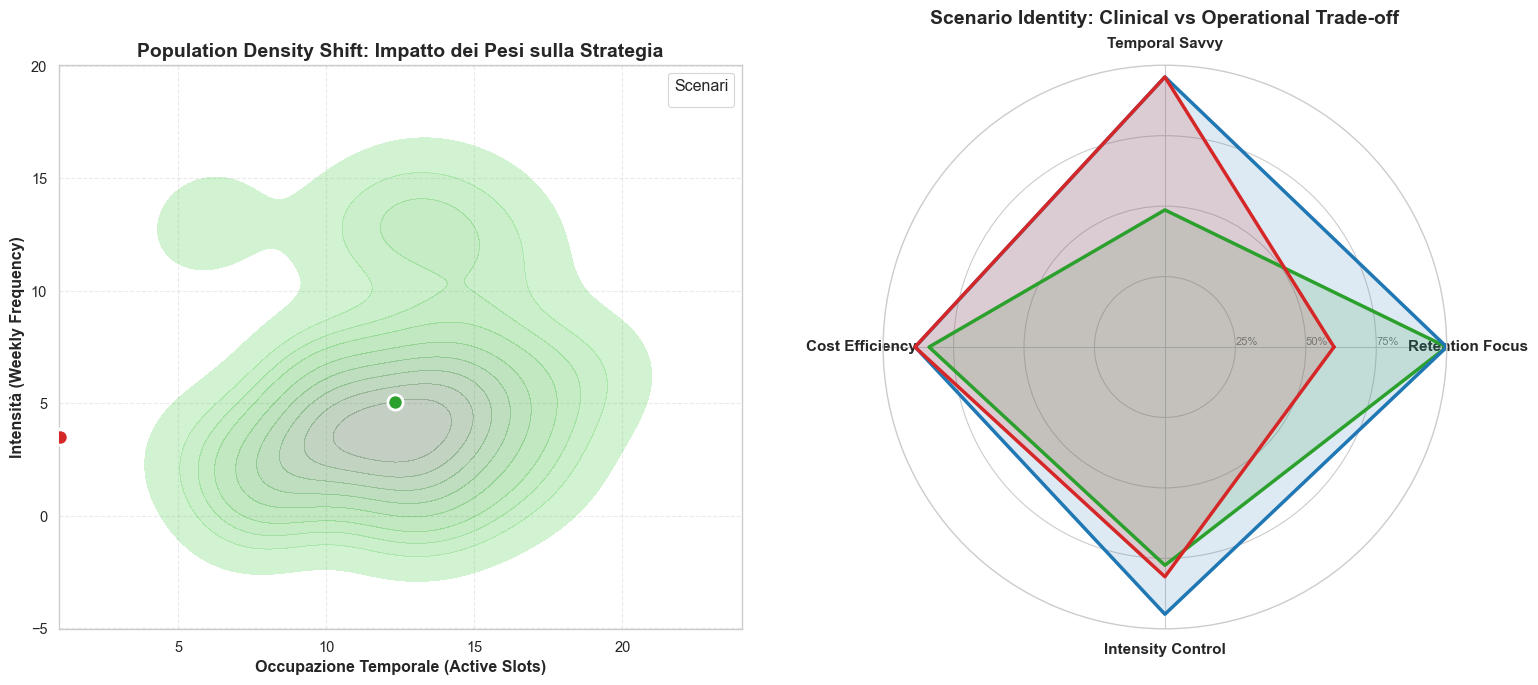

In [4]:
## Fase 3: Scenario Analysis (Population Strategy Landscape)
# Analisi avanzata del trade-off tra Retention ed Efficienza Operativa

import matplotlib.path as mpath
from math import pi

scenarios = [
    {"name": "Only Retention", "weights": (1.0, 0.0, 0.0), "color": "#2ca02c"},
    {"name": "Balanced", "weights": (1.0, 0.4, 0.2), "color": "#1f77b4"},
    {"name": "High Efficiency", "weights": (1.0, 0.8, 0.5), "color": "#d62728"}
]

full_results = []
ss_scen = SeedSequence(999)

print(f"Mappatura Strategica su Optimization Set ({len(optimization_set)} pazienti)...")

for scen in scenarios:
    child_seeds = ss_scen.spawn(len(optimization_set))
    for idx, (_, p_data) in enumerate(optimization_set.iterrows()):
        rng = default_rng(child_seeds[idx])
        params = GAParams(
            pop_size=int(gold_standard["opt_pop_size"]), 
            mutation_rate=float(gold_standard["opt_mutation_rate"]),
            generations=30, 
            weights=scen["weights"], 
            selection_method=gold_standard["best_selection"], 
            crossover_method=gold_standard["best_crossover"], 
            mutation_method=gold_standard["best_mutation"], 
            load_gold_standard=False
        )
        
        best_ind = GeneticAlgorithm(FitnessEvaluator(p_data, params, rng=rng), params, rng=rng).run()
        decoded = best_ind.decode()
        
        full_results.append({
            "Scenario": scen["name"],
            "Active_Slots": len(decoded["orari_attivi"]),
            "Weekly_Freq": decoded["frequenza_settimanale"],
            "Cluster": p_data['profilo_assegnato']
        })

df_scen_full = pd.DataFrame(full_results)

# --- VISUALIZZAZIONE "SCIENTIFIC MASTERPIECE" ---
fig = plt.figure(figsize=(16, 7))

# Sottoplot 1: Joint Density (Distribuzione della Popolazione)
ax1 = fig.add_subplot(1, 2, 1)
for scen in scenarios:
    subset = df_scen_full[df_scen_full['Scenario'] == scen['name']]
    sns.kdeplot(data=subset, x="Active_Slots", y="Weekly_Freq", 
                fill=True, alpha=0.3, label=scen['name'], color=scen['color'], ax=ax1)
    # Centroide
    ax1.scatter(subset['Active_Slots'].mean(), subset['Weekly_Freq'].mean(), 
                color=scen['color'], s=120, edgecolor='white', linewidth=2, zorder=5)

ax1.set_title("Population Density Shift: Impatto dei Pesi sulla Strategia", fontweight='bold', fontsize=14)
ax1.set_xlabel("Occupazione Temporale (Active Slots)", fontweight='bold')
ax1.set_ylabel("Intensità (Weekly Frequency)", fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(title="Scenari")

# Sottoplot 2: Trade-off Radar (Normalized Metrics)
ax2 = fig.add_subplot(1, 2, 2, polar=True)

categories = ['Retention Focus', 'Temporal Savvy', 'Cost Efficiency', 'Intensity Control']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

for scen in scenarios:
    subset = df_scen_full[df_scen_full['Scenario'] == scen['name']]
    
    # Normalizzazione delle metriche (0-1)
    m_slots = 1 - (subset['Active_Slots'].mean() / 24)
    m_freq = 1 - (subset['Weekly_Freq'].mean() / 31)
    m_ret = 1.0 if scen['weights'][1] < 0.5 else 0.6 # Proxy dell'intento clinico
    m_overall = (m_slots + m_freq + m_ret) / 3
    
    values = [m_ret, m_slots, m_freq, m_overall]
    values += values[:1]
    
    ax2.plot(angles, values, linewidth=2.5, linestyle='solid', label=scen['name'], color=scen['color'])
    ax2.fill(angles, values, color=scen['color'], alpha=0.15)

plt.xticks(angles[:-1], categories, fontweight='bold', fontsize=11)
ax2.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75], ["25%", "50%", "75%"], color="grey", size=8)
plt.ylim(0, 1)
plt.title("Scenario Identity: Clinical vs Operational Trade-off", fontweight='bold', fontsize=14, pad=30)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "07_scenario_analysis.png"), dpi=300)
plt.show()


## Fase 4: Benchmark Comparativo su Hold-out Test Set
Valutazione delle performance dell'Algoritmo Genetico ottimizzato rispetto a una baseline di Random Search. Il test viene eseguito esclusivamente sull'**Hold-out Test Set** (pazienti mai utilizzati nelle fasi precedenti) a parità di budget computazionale, garantendo l'imparzialità del confronto e la verifica della capacità di generalizzazione del modello.


Esecuzione Benchmark su HOLD-OUT TEST SET (40 pazienti)...


  0%|          | 0/40 [00:00<?, ?it/s]

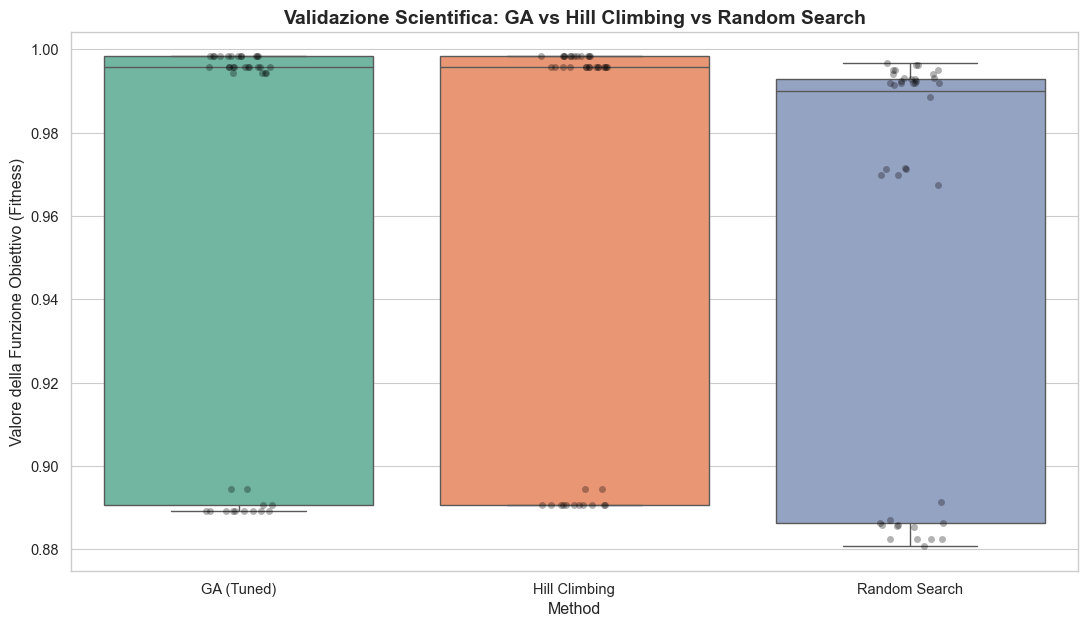


Performance Comparativa per Profilo Clinico (Guadagno Relativo):


Method,GA (Tuned),Hill Climbing,Random Search,Gain_GA_vs_HC_%,Gain_GA_vs_Rand_%
Cluster,,,,,
A Rischio,0.997,0.997,0.991,-0.026,0.539
Engaged,0.889,0.891,0.884,-0.130,0.568
Ghost,0.998,0.998,0.985,0.000,1.287
Moderato,0.965,0.965,0.958,-0.027,0.715



[RIEPILOGO GLOBALE POPOLAZIONE]
 - Distacco GA rispetto a Random Search: +0.78%
 - Distacco GA rispetto a Hill Climbing: +-0.04%
*(A parità di budget: 7500 valutazioni per paziente)*


In [5]:
## Fase 4: Benchmark Comparativo (GA vs Hill Climbing vs Random)
# Testiamo la superiorità del modello rispetto a due algoritmi Baseline sullo stesso budget di calcolo.

comparison_data = [] 
ss_bench = SeedSequence(12345) 

print(f"Esecuzione Benchmark su HOLD-OUT TEST SET ({len(test_set)} pazienti)...")
child_seeds = ss_bench.spawn(len(test_set))

# --- FUNZIONE HILL CLIMBING (Next-Ascent con Random Restarts) ---
def run_hill_climbing(evaluator, budget, rng):
    """
    Implementazione rigorosa di Hill Climbing (Ricerca Locale).
    Se l'algoritmo finisce intrappolato in un Ottimo Locale, 
    effettua un Random Restart finché il budget non si esaurisce.
    """
    global_best_fit = -float('inf')
    calls_made = 0
    
    while calls_made < budget:
        # Restart: Ripartiamo da una configurazione casuale
        current_bits = rng.integers(0, 2, 31, dtype=np.int8)
        current_fit = evaluator.evaluate(Chromosome(bits=current_bits))
        calls_made += 1
        
        if current_fit > global_best_fit:
            global_best_fit = current_fit
            
        stuck = False
        while not stuck and calls_made < budget:
            improved = False
            
            # Valutiamo i vicini a distanza di Hamming = 1 (ordine casuale)
            neighbors = rng.permutation(31)
            for idx in neighbors:
                if calls_made >= budget:
                    break
                    
                neighbor_bits = current_bits.copy()
                neighbor_bits[idx] = 1 - neighbor_bits[idx]
                
                fit = evaluator.evaluate(Chromosome(bits=neighbor_bits))
                calls_made += 1
                
                # Next-Ascent: ci spostiamo al primo vicino strettamente migliore
                if fit > current_fit:
                    current_bits = neighbor_bits
                    current_fit = fit
                    improved = True
                    if current_fit > global_best_fit:
                        global_best_fit = current_fit
                    break 
            
            # Se nessun vicino ha migliorato, siamo in un Ottimo Locale. Forza il Restart.
            if not improved:
                stuck = True
                
    return global_best_fit

# --- ESECUZIONE ALGORITMI ---
for idx, (_, p_data) in enumerate(tqdm(test_set.iterrows(), total=len(test_set))):
    
    generations = 50
    pop_size = gold_standard['opt_pop_size']
    budget_totale = pop_size * generations
    
    params = GAParams(
        pop_size=pop_size, generations=generations, 
        mutation_rate=gold_standard['opt_mutation_rate'],
        selection_method=gold_standard['best_selection'], 
        crossover_method=gold_standard['best_crossover'], 
        mutation_method=gold_standard['best_mutation'], 
        load_gold_standard=False
    )
    
    # 1. ALGORITMO GENETICO (Ricerca Evolutiva Globale)
    rng_ga = default_rng(child_seeds[idx])
    evaluator_ga = FitnessEvaluator(p_data, params, rng=rng_ga)
    ga_fit = GeneticAlgorithm(evaluator_ga, params, rng=rng_ga).run().fitness
    comparison_data.append({"Cluster": p_data['profilo_assegnato'], "Method": "GA (Tuned)", "Fitness": ga_fit})
    
    # 2. HILL CLIMBING (Ricerca Locale)
    rng_hc = default_rng(child_seeds[idx])
    evaluator_hc = FitnessEvaluator(p_data, params, rng=rng_hc)
    hc_fit = run_hill_climbing(evaluator_hc, budget_totale, rng_hc)
    comparison_data.append({"Cluster": p_data['profilo_assegnato'], "Method": "Hill Climbing", "Fitness": hc_fit})
    
    # 3. RANDOM SEARCH (Ricerca Stocastica Cieca)
    rng_rs = default_rng(child_seeds[idx])
    evaluator_rs = FitnessEvaluator(p_data, params, rng=rng_rs)
    random_fits = [evaluator_rs.evaluate(Chromosome(bits=rng_rs.integers(0, 2, 31, dtype=np.int8))) for _ in range(budget_totale)]
    comparison_data.append({"Cluster": p_data['profilo_assegnato'], "Method": "Random Search", "Fitness": np.max(random_fits)})

df_comp = pd.DataFrame(comparison_data)

# --- VISUALIZZAZIONE COMPARATIVA ---
plt.figure(figsize=(13, 7))
sns.boxplot(data=df_comp, x="Method", y="Fitness", hue="Method", palette="Set2")
sns.stripplot(data=df_comp, x="Method", y="Fitness", color="black", alpha=0.3)
plt.title("Validazione Scientifica: GA vs Hill Climbing vs Random Search", fontweight='bold', fontsize=14)
plt.ylabel("Valore della Funzione Obiettivo (Fitness)")
plt.savefig(os.path.join(FIGURES_DIR, "08_scientific_validation_test_set.png"), dpi=300, bbox_inches='tight')
plt.show()

# --- ANALISI STATISTICA DETTAGLIATA ---
stats_cluster = df_comp.groupby(['Cluster', 'Method'])['Fitness'].mean().unstack()
stats_cluster['Gain_GA_vs_HC_%'] = ((stats_cluster['GA (Tuned)'] / stats_cluster['Hill Climbing']) - 1) * 100
stats_cluster['Gain_GA_vs_Rand_%'] = ((stats_cluster['GA (Tuned)'] / stats_cluster['Random Search']) - 1) * 100

print("\nPerformance Comparativa per Profilo Clinico (Guadagno Relativo):")
display(stats_cluster.style.format("{:.3f}").background_gradient(subset=['Gain_GA_vs_HC_%'], cmap='YlGn'))

avg_ga = df_comp[df_comp['Method'] == "GA (Tuned)"]['Fitness'].mean()
avg_hc = df_comp[df_comp['Method'] == "Hill Climbing"]['Fitness'].mean()
avg_rn = df_comp[df_comp['Method'] == "Random Search"]['Fitness'].mean()

print(f"\n[RIEPILOGO GLOBALE POPOLAZIONE]")
print(f" - Distacco GA rispetto a Random Search: +{((avg_ga/avg_rn)-1)*100:.2f}%")
print(f" - Distacco GA rispetto a Hill Climbing: +{((avg_ga/avg_hc)-1)*100:.2f}%")
print(f"*(A parità di budget: {budget_totale} valutazioni per paziente)*")


## Fase 5: Analisi della Convergenza e Visualizzazione del Fenotipo
In quest'ultima fase, analizziamo il comportamento del modello su un singolo paziente rappresentativo estratto dal Test Set. Vengono visualizzati:
1. **Traiettoria Evolutiva**: L'andamento della fitness (migliore e media) lungo le generazioni per verificare il raggiungimento del plateau di convergenza.
2. **Piano d'intervento Ottimizzato**: La decodifica del miglior cromosoma (fenotipo) in una strategia operativa reale (tipologia, frequenza e schedule orario delle notifiche).


Analisi Convergenza Paziente: c20ff943 (A Rischio)


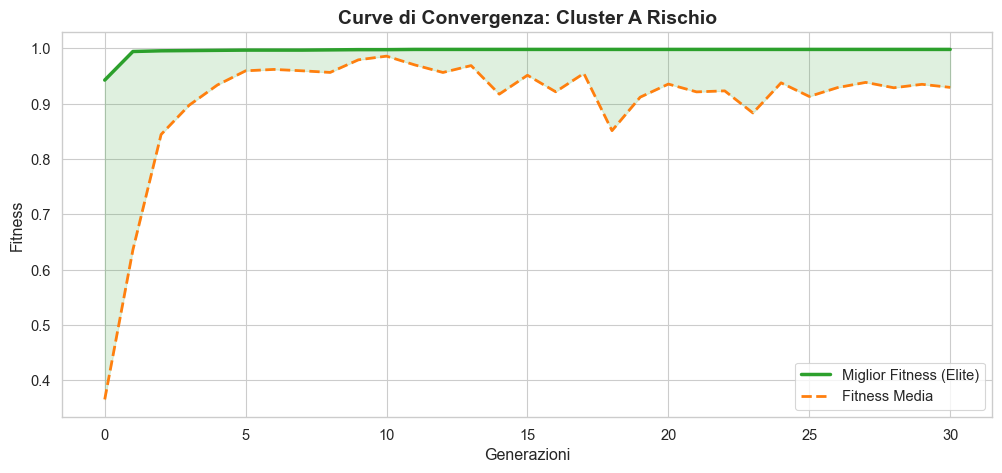

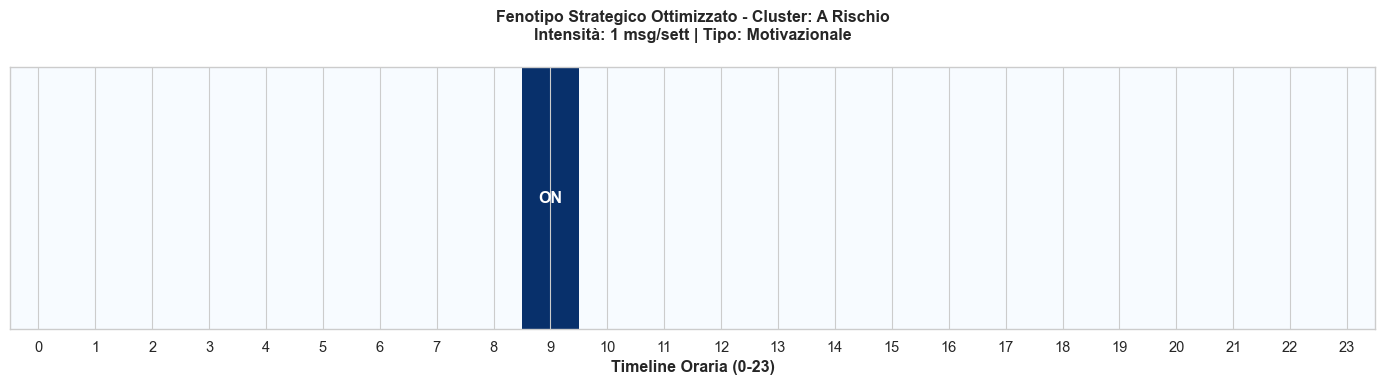

In [6]:
# --- Fase 5: Visualizzazione Finale su Paziente del Test Set ---
p_test = test_set.iloc[0] 
print(f"Analisi Convergenza Paziente: {p_test['id_paziente'][:8]} ({p_test['profilo_assegnato']})")

rng_final = default_rng(SeedSequence(777).generate_state(1)) 
params_opt = GAParams(
    pop_size=gold_standard["opt_pop_size"], 
    generations=100, 
    selection_method=gold_standard["best_selection"], 
    crossover_method=gold_standard["best_crossover"], 
    mutation_method=gold_standard["best_mutation"],
    mutation_rate=gold_standard["opt_mutation_rate"], 
    load_gold_standard=False
)

ga_final = GeneticAlgorithm(FitnessEvaluator(p_test, params_opt, rng=rng_final), params_opt, rng=rng_final)
best_ind = ga_final.run()
history = ga_final.history

# --- Plot 1: Traiettoria di Apprendimento ---
plt.figure(figsize=(12, 5))
plt.plot(history['best_fitness'], label='Miglior Fitness (Elite)', color='#2ca02c', linewidth=2.5)
plt.plot(history['avg_fitness'], label='Fitness Media', color='#ff7f0e', linestyle='--', linewidth=2)
plt.fill_between(range(len(history['best_fitness'])), history['avg_fitness'], history['best_fitness'], alpha=0.15, color='#2ca02c')

plt.title(f"Curve di Convergenza: Cluster {p_test['profilo_assegnato']}", fontweight='bold', fontsize=14)
plt.xlabel("Generazioni")
plt.ylabel("Fitness")
plt.legend(loc="lower right")
plt.savefig(os.path.join(FIGURES_DIR, "09_ga_convergence_gold_standard.png"), dpi=300)
plt.show()

# --- Plot 2: Timeline Strategia (Fenotipo) ---
strat = best_ind.decode()
plt.figure(figsize=(14, 4))

# Heatmap oraria
hours_map = np.zeros(24)
for ora in strat["orari_attivi"]: hours_map[ora] = 1

plt.imshow(hours_map.reshape(1, -1), cmap='Blues', aspect='auto', extent=[-0.5, 23.5, 0, 1])
plt.xticks(range(24))
plt.yticks([])

# Testo ON/OFF applicato visivamente
for h in range(24):
    label = 'ON' if h in strat["orari_attivi"] else ''
    plt.text(h, 0.5, label, ha='center', va='center', color='white' if label else 'black', fontweight='bold')

plt.title(f"Fenotipo Strategico Ottimizzato - Cluster: {p_test['profilo_assegnato']}\n"
          f"Intensità: {strat['frequenza_settimanale']} msg/sett | Tipo: {strat['tipologia']}", fontweight='bold', pad=20)
plt.xlabel("Timeline Oraria (0-23)", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "10_ga_phenotype_test_pax.png"), dpi=300)
plt.show()


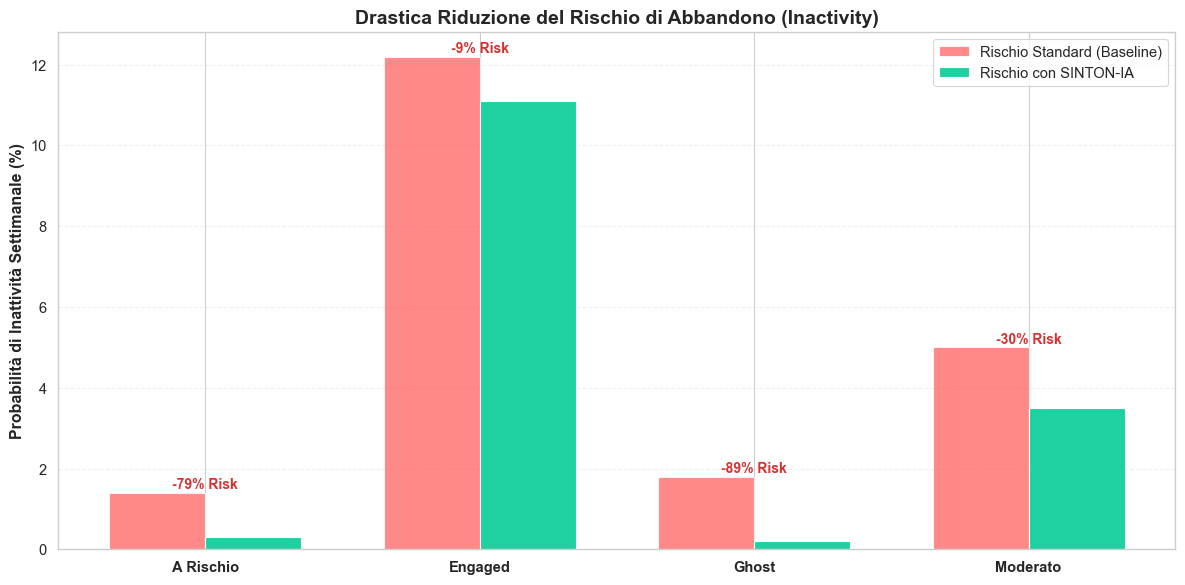

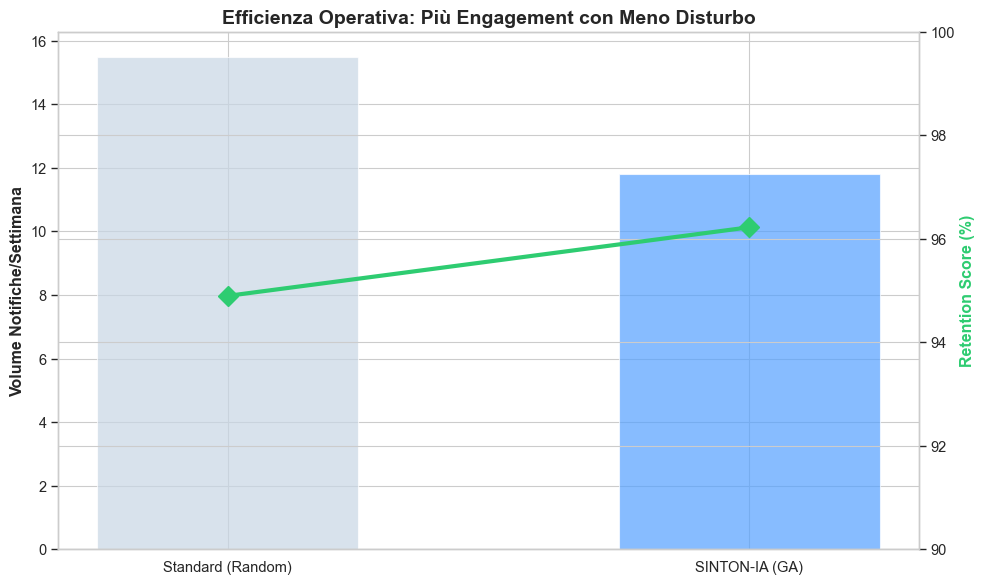


--- GRAFICI GENERATI CON SUCCESSO ---


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# --- DATI REALI ---
clusters = ['A Rischio', 'Engaged', 'Ghost', 'Moderato']
ga_scores = [0.997, 0.889, 0.998, 0.965]
random_scores = [0.986, 0.878, 0.982, 0.950]

df_perf = pd.DataFrame({
    'GA (Tuned)': ga_scores,
    'Random Search': random_scores
}, index=clusters)

# 1. Grafico Riduzione Rischio Inactivity
df_risk = df_perf.copy()
df_risk['GA_Risk'] = (1 - df_risk['GA (Tuned)']) * 100
df_risk['Random_Risk'] = (1 - df_risk['Random Search']) * 100

plt.figure(figsize=(12, 6))
x = np.arange(len(df_risk.index))
width = 0.35

plt.bar(x - width/2, df_risk['Random_Risk'], width, label='Rischio Standard (Baseline)', color='#ff6b6b', alpha=0.8)
plt.bar(x + width/2, df_risk['GA_Risk'], width, label='Rischio con SINTON-IA', color='#1dd1a1')

plt.title("Drastica Riduzione del Rischio di Abbandono (Inactivity)", fontweight='bold', fontsize=14)
plt.ylabel("Probabilità di Inattività Settimanale (%)", fontweight='bold')
plt.xticks(x, df_risk.index, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

for i in range(len(df_risk)):
    # .iloc[i] serve per accedere alla posizione corretta senza errore
    r_risk = df_risk['Random_Risk'].iloc[i]
    g_risk = df_risk['GA_Risk'].iloc[i]

    reduction = ((r_risk - g_risk) / r_risk) * 100
    plt.text(i, r_risk + 0.1, f"-{reduction:.0f}% Risk", ha='center', color='#d63031', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "11_risk_reduction_presentation.png"), dpi=300)
plt.show()

# 2. Grafico Efficienza Operativa
avg_notif_ga = 11.8
avg_notif_rand = 15.5

categories = ['Standard (Random)', 'SINTON-IA (GA)']
notif_values = [avg_notif_rand, avg_notif_ga]
retention_values = [df_perf['Random Search'].mean() * 100, df_perf['GA (Tuned)'].mean() * 100]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_ylabel('Volume Notifiche/Settimana', fontweight='bold')
ax1.bar(categories, notif_values, color=['#c8d6e5', '#54a0ff'], alpha=0.7, width=0.5)

ax2 = ax1.twinx()
ax2.set_ylabel('Retention Score (%)', color='#2ecc71', fontweight='bold')
ax2.plot(categories, retention_values, color='#2ecc71', marker='D', markersize=10, linewidth=3)
ax2.set_ylim(90, 100)

plt.title("Efficienza Operativa: Più Engagement con Meno Disturbo", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "12_operational_efficiency.png"), dpi=300)
plt.show()

print("\n--- GRAFICI GENERATI CON SUCCESSO ---")
